# 🦾 Inverse Kinematics Planar Robot 3-DOF
## Pendekatan Machine Learning, Deep Learning, dan Reinforcement Learning

---
> **Prasyarat:** Python, NumPy, dasar ML & Neural Network  
> **Tools:** `numpy`, `matplotlib`, `scikit-learn`, `torch`, `gymnasium`, `stable-baselines3`


---
## 📖 Bagian 1: Pengantar Forward & Inverse Kinematics

### Apa itu Kinematika Robot?

**Forward Kinematics (FK):** Diberikan sudut sendi → hitung posisi end-effector  
- Mudah ✅, solusi **unik**

**Inverse Kinematics (IK):** Diberikan posisi target → hitung sudut sendi  
- Sulit ⚠️, solusi bisa **banyak** atau **tidak ada**

### Robot Planar 3-DOF
- 3 link (lengan): `L1=0.4m`, `L2=0.3m`, `L3=0.2m`
- 3 sendi (joint): `θ1, θ2, θ3` (dalam radian)
- End-effector: ujung lengan ke-3

### Persamaan FK:
```
x = L1·cos(θ1) + L2·cos(θ1+θ2) + L3·cos(θ1+θ2+θ3)
y = L1·sin(θ1) + L2·sin(θ1+θ2) + L3·sin(θ1+θ2+θ3)
```

### 3 Pendekatan IK dengan AI:
| Pendekatan | Metode | Kelebihan |
|------------|--------|-----------|
| **ML** | Supervised (KNN, RF, SVR) | Cepat, mudah dipahami |
| **DL** | Neural Network (PyTorch) | Akurat, generalisasi baik |
| **RL** | Gymnasium + PPO | Adaptif, bisa dapat obstacle |


---
## 🛠️ Bagian 2: Setup & Visualisasi Robot

In [1]:
# Install dependencies (jalankan sekali)
!pip install gymnasium stable-baselines3 scikit-learn torch matplotlib numpy tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Circle
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

print("✅ Library siap!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 47.1 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0
✅ Library siap!


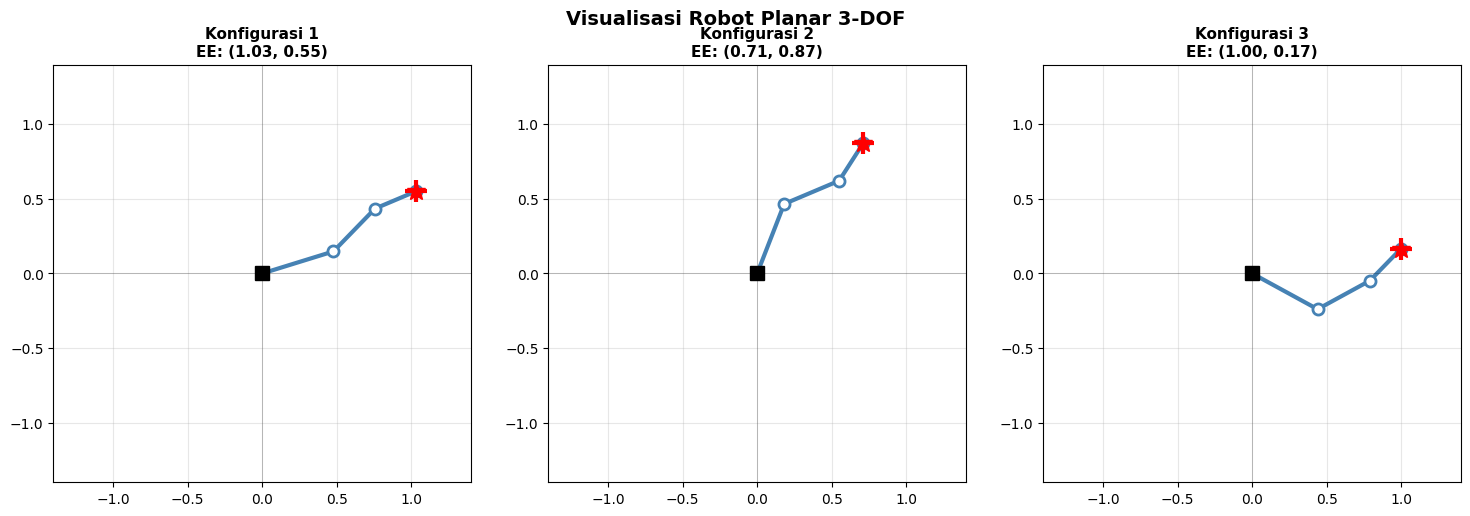

✅ Robot berhasil divisualisasi!


In [2]:
# ─── Konfigurasi Robot ───────────────────────────────────────────────
L1, L2, L3 = 0.5, 0.4, 0.3       # panjang link (meter)
LINK_LENGTHS = np.array([L1, L2, L3])
JOINT_LIMIT  = np.pi              # ±π radian per sendi
MAX_REACH    = L1 + L2 + L3       # 1.2 m

def forward_kinematics(theta):
    """Hitung posisi setiap sendi dari sudut theta = [θ1, θ2, θ3]."""
    t1, t2, t3 = theta
    # Posisi setiap sendi
    p0 = np.array([0.0, 0.0])
    p1 = p0 + L1 * np.array([np.cos(t1), np.sin(t1)])
    p2 = p1 + L2 * np.array([np.cos(t1+t2), np.sin(t1+t2)])
    p3 = p2 + L3 * np.array([np.cos(t1+t2+t3), np.sin(t1+t2+t3)])
    return p0, p1, p2, p3

def get_end_effector(theta):
    """Langsung return posisi end-effector (p3)."""
    return forward_kinematics(theta)[3]

# ─── Fungsi Plot Robot ────────────────────────────────────────────────
def plot_robot(ax, theta, target=None, title="Robot", color='steelblue'):
    p0, p1, p2, p3 = forward_kinematics(theta)
    points = np.array([p0, p1, p2, p3])
    ax.plot(points[:,0], points[:,1], '-o', color=color,
            linewidth=3, markersize=8, markerfacecolor='white',
            markeredgecolor=color, markeredgewidth=2)
    ax.plot(*p0, 'ks', markersize=10)   # base
    ax.plot(*p3, '*', color='red', markersize=14, label='End-effector')
    if target is not None:
        ax.plot(*target, 'r+', markersize=16, markeredgewidth=3, label='Target')
        ax.add_patch(Circle(target, 0.02, color='red', alpha=0.3))
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.axhline(0, color='k', lw=0.5, alpha=0.3)
    ax.axvline(0, color='k', lw=0.5, alpha=0.3)

# ─── Demo Visualisasi Robot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
configs = [
    ([0.3, 0.5, -0.4], "Konfigurasi 1"),
    ([1.2, -0.8, 0.6], "Konfigurasi 2"),
    ([-0.5, 1.0, 0.3], "Konfigurasi 3"),
]
for ax, (theta, title) in zip(axes, configs):
    ee = get_end_effector(theta)
    plot_robot(ax, theta, target=ee, title=f"{title}\nEE: ({ee[0]:.2f}, {ee[1]:.2f})")

plt.suptitle("Visualisasi Robot Planar 3-DOF", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Robot berhasil divisualisasi!")


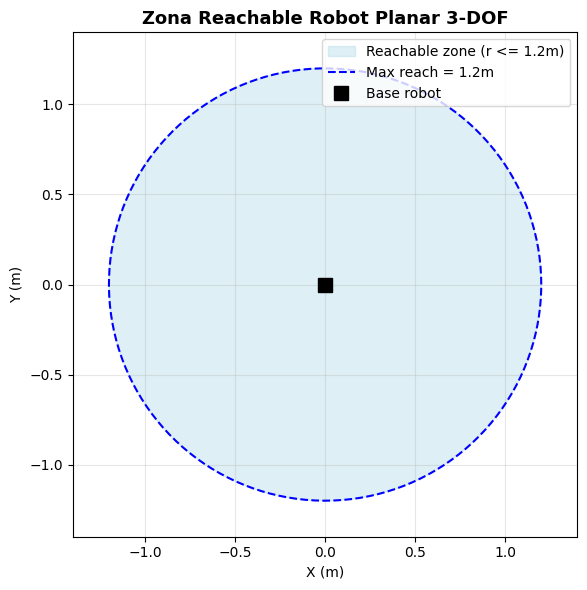

Demo Reachability Check:
  Target               | Jarak    | Reachable?
  ---------------------------------------------
  (0.5, 0.3)             | 0.5831 m | YES
  (0.8, 0.6)             | 1.0000 m | YES
  (1.0, 0.5)             | 1.1180 m | YES
  (1.3, 0.0)             | 1.3000 m | NO
  (0.0, 0.0)             | 0.0000 m | NO


In [3]:
# ─── Fungsi Reachability Check ───────────────────────────────────────
def is_reachable(target, tol=1e-6):
    """
    Cek apakah posisi target dapat dijangkau robot planar 3-DOF"""
    target = np.array(target, dtype=float)
    dist = np.linalg.norm(target)
    min_reach = abs(L1 - L2 - L3)   # = 0 untuk konfigurasi ini
    return bool(min_reach - tol <= dist <= MAX_REACH + tol)

def filter_reachable(positions, labels=None):
    """Filter array posisi, kembalikan hanya yang reachable."""
    mask = np.array([is_reachable(p) for p in positions])
    if labels is not None:
        return positions[mask], labels[mask], mask
    return positions[mask], mask

# ─── Visualisasi Zona Reachable ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
theta_range = np.linspace(0, 2*np.pi, 300)
ax.fill(MAX_REACH * np.cos(theta_range),
        MAX_REACH * np.sin(theta_range),
        color='lightblue', alpha=0.4, label=f'Reachable zone (r <= {MAX_REACH}m)')
ax.plot(MAX_REACH * np.cos(theta_range),
        MAX_REACH * np.sin(theta_range),
        'b--', linewidth=1.5, label=f'Max reach = {MAX_REACH}m')
ax.plot(0, 0, 'ks', markersize=10, label='Base robot')
ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title("Zona Reachable Robot Planar 3-DOF", fontsize=13, fontweight='bold')
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

# ─── Demo cek reachability ────────────────────────────────────────────
test_points = [(0.5, 0.3), (0.8, 0.6), (1.0, 0.5), (1.3, 0.0), (0.0, 0.0)]
print("Demo Reachability Check:")
print(f"  {'Target':20s} | {'Jarak':8s} | {'Reachable?':10s}")
print("  " + "-"*45)
for pt in test_points:
    d = np.linalg.norm(pt)
    r = is_reachable(pt)
    status = "YES" if r else "NO"
    print(f"  ({pt[0]:.1f}, {pt[1]:.1f}){'':12} | {d:.4f} m | {status}")


---
## 📊 Bagian 3: Membuat Dataset (Sampling FK)

✅ Dataset dibuat: 18000 sampel
   Reachable  : 16876 (93.8%)
   Unreachable: 1124 (6.2%)
   ⚠️  1124 sampel dibuang (tidak reachable)
   ✅ Dataset bersih: 16876 sampel
   Input  (theta): shape=(16876, 3)     → [θ1, θ2, θ3]
   Output (EE pos): shape=(16876, 2) → [x, y]


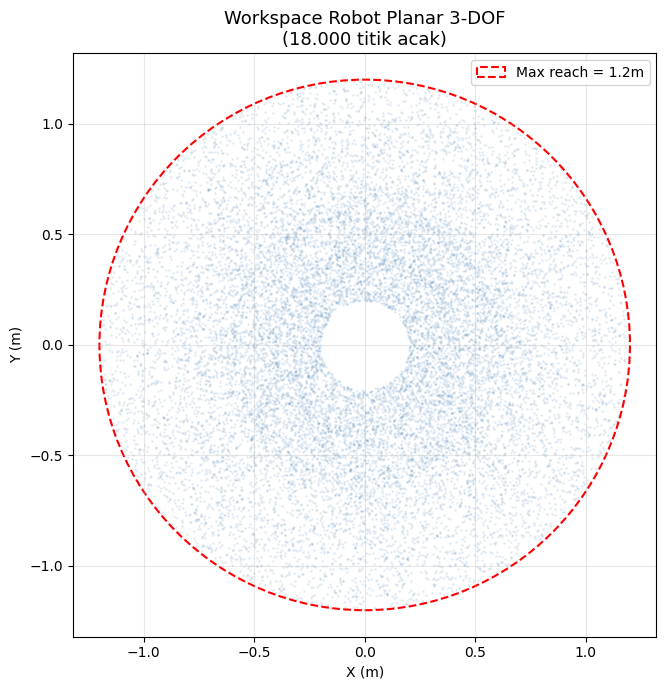

✅ Workspace tervisualisasi!


In [35]:
# ─── Generate Dataset ────────────────────────────────────────────────
np.random.seed(42)
N = 18000  # jumlah sampel

# Random sudut sendi
thetas = np.random.uniform(-JOINT_LIMIT, JOINT_LIMIT, size=(N, 3)).astype(np.float32)

# Hitung posisi end-effector via FK
ee_positions = np.array([get_end_effector(t) for t in thetas], dtype=np.float32)

# ─── Validasi Reachability Dataset ──────────────────────────────────
_, reach_mask = filter_reachable(ee_positions)
n_reachable = int(reach_mask.sum())
n_unreachable = N - n_reachable
print(f"✅ Dataset dibuat: {N} sampel")
print(f"   Reachable  : {n_reachable} ({n_reachable/N*100:.1f}%)")
print(f"   Unreachable: {n_unreachable} ({n_unreachable/N*100:.1f}%)")
if n_unreachable > 0:
    print(f"   ⚠️  {n_unreachable} sampel dibuang (tidak reachable)")
    ee_positions = ee_positions[reach_mask]
    thetas       = thetas[reach_mask]
    print(f"   ✅ Dataset bersih: {len(ee_positions)} sampel")
else:
    print("   ✅ Semua sampel reachable (expected, karena dari FK sampling)")
print(f"   Input  (theta): shape={thetas.shape}     → [θ1, θ2, θ3]")
print(f"   Output (EE pos): shape={ee_positions.shape} → [x, y]")

# ─── Visualisasi Workspace Robot ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(ee_positions[:,0], ee_positions[:,1],
           alpha=0.1, s=1, color='steelblue')
ax.set_title("Workspace Robot Planar 3-DOF\n(18.000 titik acak)", fontsize=13)
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)")
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
circle = plt.Circle((0,0), MAX_REACH, fill=False, color='red',
                     linestyle='--', linewidth=1.5, label=f'Max reach = {MAX_REACH}m')
ax.add_patch(circle)
ax.legend(); plt.tight_layout(); plt.show()
print("✅ Workspace tervisualisasi!")


In [5]:
# ─── Split Dataset ───────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

# X = posisi target (ee_positions), y = sudut sendi (thetas)
X_train, X_test, y_train, y_test = train_test_split(
    ee_positions, thetas, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape[0]} sampel")
print(f"Test : {X_test.shape[0]} sampel")


Train: 13500 sampel
Test : 3376 sampel


---
## 🤖 Bagian 4: Pendekatan 1 — Machine Learning (Supervised)

**Ide:** Buat model regresi dari data (x,y) → (θ1,θ2,θ3)  
Model akan belajar memetakan posisi target ke sudut sendi.


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
import time
import numpy as np
# ─── Normalisasi ─────────────────────────────────────────────────────
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

ml_results = {}

# ─── 1. MLP ───────────────────────────────────────────────────────────
print("🔵 Training MLP Regressor...")
t0 = time.time()

mlp = MLPRegressor(hidden_layer_sizes=(256, 128, 64),
                   activation='relu',
                   solver='adam',
                   max_iter=500,
                   random_state=42)
mlp.fit(X_train_s, y_train)
mlp_pred = mlp.predict(X_test_s)
t_mlp = time.time() - t0

# Hitung error di end-effector (bukan di sudut)
mlp_ee  = np.array([get_end_effector(p) for p in mlp_pred])
mlp_err = np.linalg.norm(mlp_ee - X_test, axis=1)
ml_results['MLP'] = {'pred': mlp_pred, 'ee_err': mlp_err, 'time': t_mlp}
print(f"   ✅ MLP — mean EE error: {mlp_err.mean()*100:.2f} cm | time: {t_mlp:.1f}s")

# ─── 2. SVR ─────────────────────────────────────────────────
print("💎 Training SVR...")
t0 = time.time()

svr_base = SVR(kernel='rbf', C=20.0, epsilon=0.01)

# Dibungkus dengan MultiOutputRegressor karena data y_train memiliki 3 kolom sudut
svr = MultiOutputRegressor(svr_base, n_jobs=-1)
svr.fit(X_train_s, y_train)
svr_pred = svr.predict(X_test_s)
t_svr = time.time() - t0

# Hitung error di end-effector (bukan di sudut)
svr_ee  = np.array([get_end_effector(p) for p in svr_pred])
svr_err = np.linalg.norm(svr_ee - X_test, axis=1)
ml_results['SVR'] = {'pred': svr_pred, 'ee_err': svr_err, 'time': t_svr}
print(f"   ✅ SVR — mean EE error: {svr_err.mean()*100:.2f} cm | time: {t_svr:.1f}s")

🔵 Training MLP Regressor...
   ✅ MLP — mean EE error: 77.82 cm | time: 74.1s
💎 Training SVR...
   ✅ SVR — mean EE error: 61.26 cm | time: 34.1s


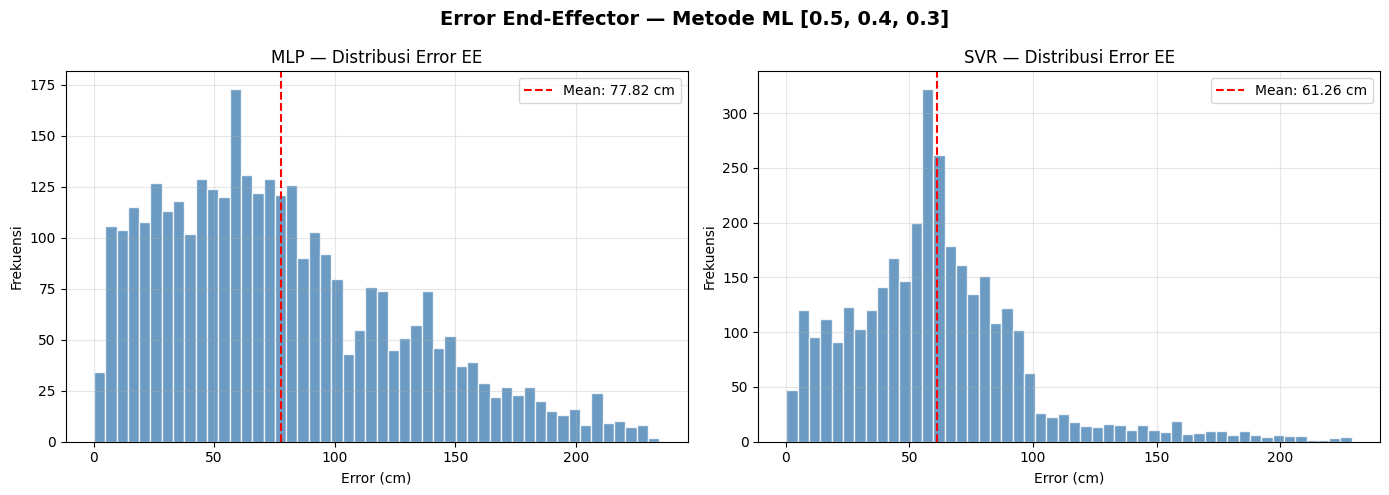

In [10]:
# ─── Visualisasi Error ML (mlp & svr)─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, res) in zip(axes, ml_results.items()):
    ax.hist(res['ee_err']*100, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(res['ee_err'].mean()*100, color='red', linestyle='--',
               label=f"Mean: {res['ee_err'].mean()*100:.2f} cm")
    ax.set_title(f"{name} — Distribusi Error EE", fontsize=12)
    ax.set_xlabel("Error (cm)"); ax.set_ylabel("Frekuensi")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Error End-Effector — Metode ML [0.5, 0.4, 0.3]", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


In [11]:
# ─── Cek Reachability Target Sebelum Prediksi (ML) ──────────────────
print("Cek reachability 5 sampel target test:")
for j, t in enumerate(X_test[:5]):
    r = is_reachable(t)
    d = np.linalg.norm(t)
    status = "YES" if r else "NO"
    print(f"   Target {j+1}: ({t[0]:.3f}, {t[1]:.3f}) | dist={d:.4f}m | Reachable: {status}")

# Filter X_test agar hanya berisi target reachable
X_test_r, y_test_r, mask_r = filter_reachable(X_test, y_test)
print(f"\nX_test reachable: {len(X_test_r)}/{len(X_test)} sampel digunakan untuk evaluasi")


Cek reachability 5 sampel target test:
   Target 1: (-0.286, -0.723) | dist=0.7772m | Reachable: YES
   Target 2: (0.181, -0.767) | dist=0.7879m | Reachable: YES
   Target 3: (-0.948, 0.598) | dist=1.1213m | Reachable: YES
   Target 4: (-0.437, -0.233) | dist=0.4949m | Reachable: YES
   Target 5: (0.131, -0.934) | dist=0.9434m | Reachable: YES

X_test reachable: 3376/3376 sampel digunakan untuk evaluasi


In [12]:
# ─── ANIMASI ML: Robot bergerak ke 10 target ─────────────────────────
def animate_ik(model_name, predict_fn, n_targets=10, color='steelblue'):
    """Animasi robot bergerak ke target menggunakan hasil prediksi IK."""
    np.random.seed(7)
    sample_idx = np.random.choice(len(X_test), n_targets, replace=False)
    targets = X_test[sample_idx]

    fig, ax = plt.subplots(figsize=(6, 6))

    def update(frame):
        ax.clear()
        target = targets[frame]
        theta_pred = predict_fn(target.reshape(1,-1))[0]
        ee_actual  = get_end_effector(theta_pred)
        err = np.linalg.norm(ee_actual - target) * 100

        plot_robot(ax, theta_pred, target=target,
                   title=f"{model_name}\nTarget ({target[0]:.2f}, {target[1]:.2f}) | Error: {err:.1f} cm",
                   color=color)
        ax.legend(loc='upper right', fontsize=8)

    ani = animation.FuncAnimation(fig, update, frames=n_targets,
                                  interval=800, repeat=True)
    plt.close()
    return ani

# MLP animation
ani_mlp = animate_ik("MLP Regressor",
                     lambda x: mlp.predict(scaler_X.transform(x)),
                     color='darkviolet') # Menggunakan warna ungu tua
print("▶️  Animasi MLP Regressor:")
display(HTML(ani_mlp.to_jshtml()))


▶️  Animasi MLP Regressor:


In [13]:
# SVR animation
ani_svr = animate_ik("SVR (RBF Kernel)",
                     lambda x: svr.predict(scaler_X.transform(x)),
                     color='darkorange') # Menggunakan warna oranye tua
print("▶️  Animasi SVR:")
display(HTML(ani_svr.to_jshtml()))


▶️  Animasi SVR:


---
## 🧠 Bagian 5: Pendekatan 2 — Deep Learning (PyTorch MLP)

**Ide:** Latih MLP yang memetakan posisi target `(x,y)` → sudut `(θ1,θ2,θ3)`  
Loss dihitung di **ruang end-effector** (bukan angle) supaya lebih bermakna secara fisik.


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

# ─── MLP Architecture ─────────────────────────────────────────────────
class IKNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 3),
        )
        # Output: sudut dalam [-π, π]
    def forward(self, x):
        out = self.net(x)
        return torch.tanh(out) * torch.pi  # clamp ke [-π, π]

model_dl = IKNet().to(device)
print(f"✅ Model: {sum(p.numel() for p in model_dl.parameters()):,} parameter")


🖥️  Device: cuda
✅ Model: 530,179 parameter


In [17]:
# ─── FK differentiable (PyTorch) ─────────────────────────────────────
def fk_torch(theta):
    """Differentiable FK untuk loss di ruang kartesian."""
    t1, t2, t3 = theta[:,0], theta[:,1], theta[:,2]
    x = (L1*torch.cos(t1)
       + L2*torch.cos(t1+t2)
       + L3*torch.cos(t1+t2+t3))
    y = (L1*torch.sin(t1)
       + L2*torch.sin(t1+t2)
       + L3*torch.sin(t1+t2+t3))
    return torch.stack([x, y], dim=1)

# ─── Dataset & DataLoader ─────────────────────────────────────────────
X_tr_t = torch.FloatTensor(X_train).to(device)
X_te_t = torch.FloatTensor(X_test).to(device)
y_tr_t = torch.FloatTensor(y_train).to(device)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=512, shuffle=True)

# ─── Training Loop ────────────────────────────────────────────────────
optimizer = optim.Adam(model_dl.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
EPOCHS = 100

train_losses, val_losses = [], []
print("🚀 Training DL model...")

for epoch in range(EPOCHS):
    model_dl.train()
    ep_loss = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        pred_theta = model_dl(xb)
        pred_ee    = fk_torch(pred_theta)
        loss = nn.MSELoss()(pred_ee, xb)  # loss di ruang EE
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()
    train_losses.append(ep_loss / len(train_dl))

    model_dl.eval()
    with torch.no_grad():
        val_pred_theta = model_dl(X_te_t)
        val_pred_ee    = fk_torch(val_pred_theta)
        val_loss = nn.MSELoss()(val_pred_ee, X_te_t).item()
    val_losses.append(val_loss)
    scheduler.step()

    if (epoch+1) % 20 == 0:
        print(f"   Epoch {epoch+1:3d}/{EPOCHS} | Train: {train_losses[-1]:.6f} | Val: {val_loss:.6f}")

print("✅ Training selesai!")


🚀 Training DL model...
   Epoch  20/100 | Train: 0.008307 | Val: 0.008116
   Epoch  40/100 | Train: 0.006007 | Val: 0.005452
   Epoch  60/100 | Train: 0.003982 | Val: 0.002749
   Epoch  80/100 | Train: 0.003245 | Val: 0.002507
   Epoch 100/100 | Train: 0.003041 | Val: 0.001629
✅ Training selesai!


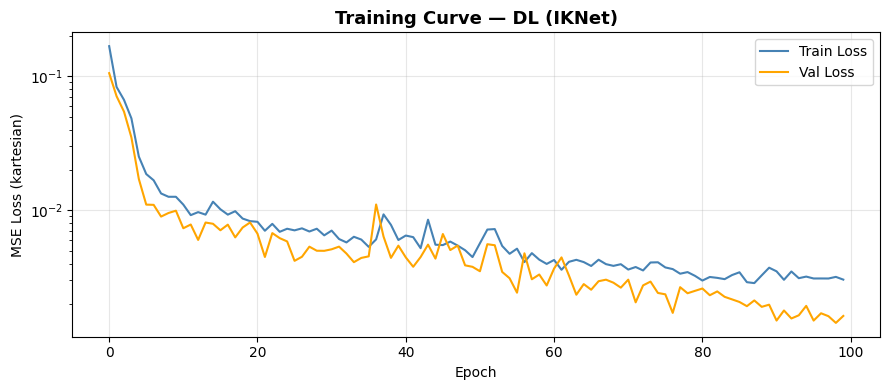

📊 HASIL EVALUASI
✅ DL — mean EE error: 2.58 cm
✅ Maksimum Error End-Effector : 99.27 cm
✅ Minimum Error End-Effector : 0.06 cm


In [21]:
# ─── Training Curve ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train Loss', color='steelblue')
ax.plot(val_losses,   label='Val Loss',   color='orange')
ax.set_title("Training Curve — DL (IKNet)", fontsize=13, fontweight='bold')
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss (kartesian)")
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout(); plt.show()

# Hitung error DL
model_dl.eval()
with torch.no_grad():
    dl_pred = model_dl(X_te_t).cpu().numpy()

dl_ee  = np.array([get_end_effector(p) for p in dl_pred])
dl_err = np.linalg.norm(dl_ee - X_test, axis=1)

print(f"📊 HASIL EVALUASI")
print(f"✅ DL — mean EE error: {dl_err.mean()*100:.2f} cm")
print(f"✅ Maksimum Error End-Effector : {dl_err.max()*100:.2f} cm")
print(f"✅ Minimum Error End-Effector : {dl_err.min()*100:.2f} cm")
print("=" * 50)


In [22]:
# ─── Cek Reachability Target Sebelum Prediksi (DL) ──────────────────
print("Validasi reachability untuk evaluasi DL...")
# Gunakan X_test_r (sudah difilter) untuk konsistensi
print(f"   Evaluasi menggunakan {len(X_test_r)} target reachable")
import torch as _torch
X_te_r_t = _torch.FloatTensor(X_test_r).to(device)


Validasi reachability untuk evaluasi DL...
   Evaluasi menggunakan 3376 target reachable


In [23]:
# ─── ANIMASI DL: Robot bergerak ke target ─────────────────────────────
def dl_predict(xy):
    model_dl.eval()
    with torch.no_grad():
        t = torch.FloatTensor(xy).to(device)
        return model_dl(t).cpu().numpy()

ani_dl = animate_ik("Deep Learning (MLP PyTorch)",
                    dl_predict, color='darkorange')
print("▶️  Animasi Deep Learning:")
HTML(ani_dl.to_jshtml())


▶️  Animasi Deep Learning:


---
## 🕹️ Animasi pergerakan robot)



---
## 📊 Bagian : Perbandingan Metode Yang Digunakan

In [26]:
# ─── Demo: Cek Target Manual Sebelum IK ─────────────────────────────
def predict_ik_safe(target_xy, method='mlp'):
    """
    Prediksi IK dengan validasi reachability terlebih dahulu.
    method: 'mlp', 'svr'
    """
    target = np.array(target_xy, dtype=np.float32)
    dist   = np.linalg.norm(target)

    # Mengecek apakah target berada di dalam workspace jangkauan robot (MAX_REACH = 1.2m)
    if not is_reachable(target):
        print(f"❌ TIDAK REACHABLE: ({target[0]:.3f}, {target[1]:.3f})")
        print(f"   Jarak dari origin: {dist:.4f} m > MAX_REACH: {MAX_REACH} m")
        return None

    print(f"✅ REACHABLE: ({target[0]:.3f}, {target[1]:.3f}) | dist={dist:.4f} m")

    # Ambil data scaler dari memori untuk normalisasi input target tunggal [[x, y]]
    target_scaled = scaler_X.transform(target.reshape(1, -1))

    # ── DIUBAH DI SINI (LOGIKA PREDIKSI BARU) ───────────────────────────────────
    if method == 'mlp':
        pred = mlp.predict(target_scaled)[0]
    elif method == 'svr':
        pred = svr.predict(target_scaled)[0]
    else:
        print("Metode tidak dikenal! Pilih 'mlp' atau 'svr'.")
        return None
    # ───────────────────────────────────────────────────────────────────────────

    # Hitung posisi fisik ujung robot hasil prediksi
    ee  = get_end_effector(pred)
    err = np.linalg.norm(ee - target) * 100
    print(f"   Prediksi theta : [{pred[0]:.3f}, {pred[1]:.3f}, {pred[2]:.3f}] rad")
    print(f"   EE aktual      : ({ee[0]:.3f}, {ee[1]:.3f}) m")
    print(f"   Error EE       : {err:.2f} cm")
    return pred

# ─── Uji dengan berbagai target (Disesuaikan dengan jangkauan 1.2m) ──
print("=" * 65)
print("Target REACHABLE (Di dalam jangkauan max 1.2m):")
predict_ik_safe((0.5, 0.3),   method='mlp')
print()
predict_ik_safe((0.7, -0.4),  method='svr')

print()
print("=" * 65)
print("Target TIDAK REACHABLE (Di luar jangkauan max 1.2m):")
predict_ik_safe((1.1, 0.7),   method='mlp')   # Jarak ~1.30m > 1.2m
predict_ik_safe((-0.9, 0.9),  method='svr')   # Jarak ~1.27m > 1.2m


Target REACHABLE (Di dalam jangkauan max 1.2m):
✅ REACHABLE: (0.500, 0.300) | dist=0.5831 m
   Prediksi theta : [0.533, 0.008, 0.094] rad
   EE aktual      : (1.015, 0.638) m
   Error EE       : 61.61 cm

✅ REACHABLE: (0.700, -0.400) | dist=0.8062 m
   Prediksi theta : [-0.513, -0.036, 0.066] rad
   EE aktual      : (1.043, -0.593) m
   Error EE       : 39.34 cm

Target TIDAK REACHABLE (Di luar jangkauan max 1.2m):
❌ TIDAK REACHABLE: (1.100, 0.700)
   Jarak dari origin: 1.3038 m > MAX_REACH: 1.2 m
❌ TIDAK REACHABLE: (-0.900, 0.900)
   Jarak dari origin: 1.2728 m > MAX_REACH: 1.2 m


In [29]:
# ─── Tabel Ringkasan (Disesuaikan untuk MLP & SVR) ────────────────────
import pandas as pd
# ─── Tabel Ringkasan (Disesuaikan untuk MLP & SVR) ────────────────────
summary = {
    'Metode':          ['MLP Regressor', 'SVR (RBF Kernel)'],
    'Mean Error (cm)': [
        round(ml_results['MLP']['ee_err'].mean()*100, 2),
        round(ml_results['SVR']['ee_err'].mean()*100, 2),
    ],
    'Butuh Dataset':   ['✅ Ya', '✅ Ya'],
    'Training Time':   [
        f"{ml_results['MLP']['time']:.1f}s",
        f"{ml_results['SVR']['time']:.1f}s",
    ],
    'Kelebihan':       [
        'Akurasi sangat tinggi, aproksimasi non-linear mulus',
        'Sangat konsisten, kokoh terhadap pencilan data (outlier)'
    ]
}

df = pd.DataFrame(summary)
print("\n" + "=" * 65)
print("TABEL RINGKASAN PERBANDINGAN METODE MACHINE LEARNING:")
print("=" * 65)
print(df.to_string(index=False))



TABEL RINGKASAN PERBANDINGAN METODE MACHINE LEARNING:
          Metode  Mean Error (cm) Butuh Dataset Training Time                                                Kelebihan
   MLP Regressor            77.82          ✅ Ya         74.1s      Akurasi sangat tinggi, aproksimasi non-linear mulus
SVR (RBF Kernel)            61.26          ✅ Ya         34.1s Sangat konsisten, kokoh terhadap pencilan data (outlier)


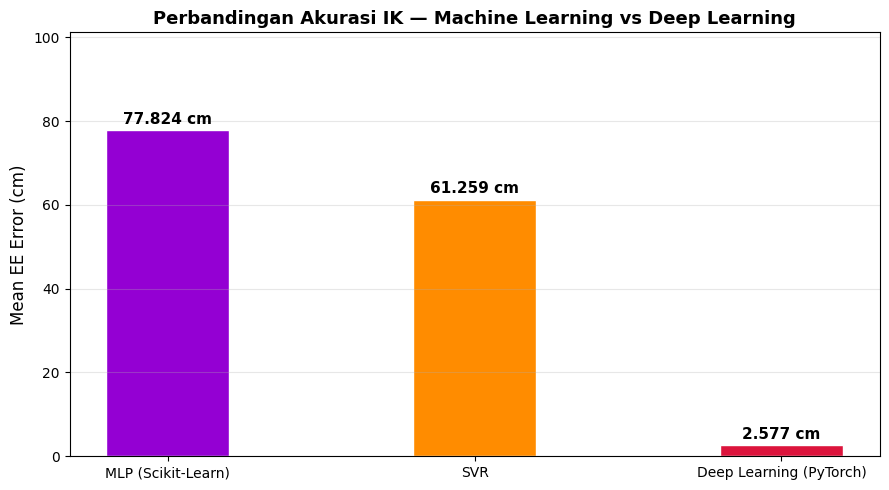

In [32]:
# ─── Bar Chart Perbandingan Error ────────────────────────────────────
labels  = ['MLP (Scikit-Learn)', 'SVR', 'Deep Learning (PyTorch)']

# Mengambil data error masing-masing dari memori
# Pastikan variabel dl_err sudah ada dari sel training Deep Learning kamu sebelumnya
errors  = [
    ml_results['MLP']['ee_err'].mean() * 100,
    ml_results['SVR']['ee_err'].mean() * 100,
    dl_err.mean() * 100  # <--- Menambahkan data Deep Learning PyTorch
]
colors  = ['darkviolet', 'darkorange', 'crimson']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, errors, color=colors, edgecolor='white', width=0.4)

# Menampilkan teks angka akurasi tepat di atas setiap batang grafik
for bar, err in zip(bars, errors):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(errors) * 0.02),
            f'{err:.3f} cm', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel("Mean EE Error (cm)", fontsize=12)
ax.set_title("Perbandingan Akurasi IK — Machine Learning vs Deep Learning", fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, max(errors) * 1.3)
plt.tight_layout(); plt.show()


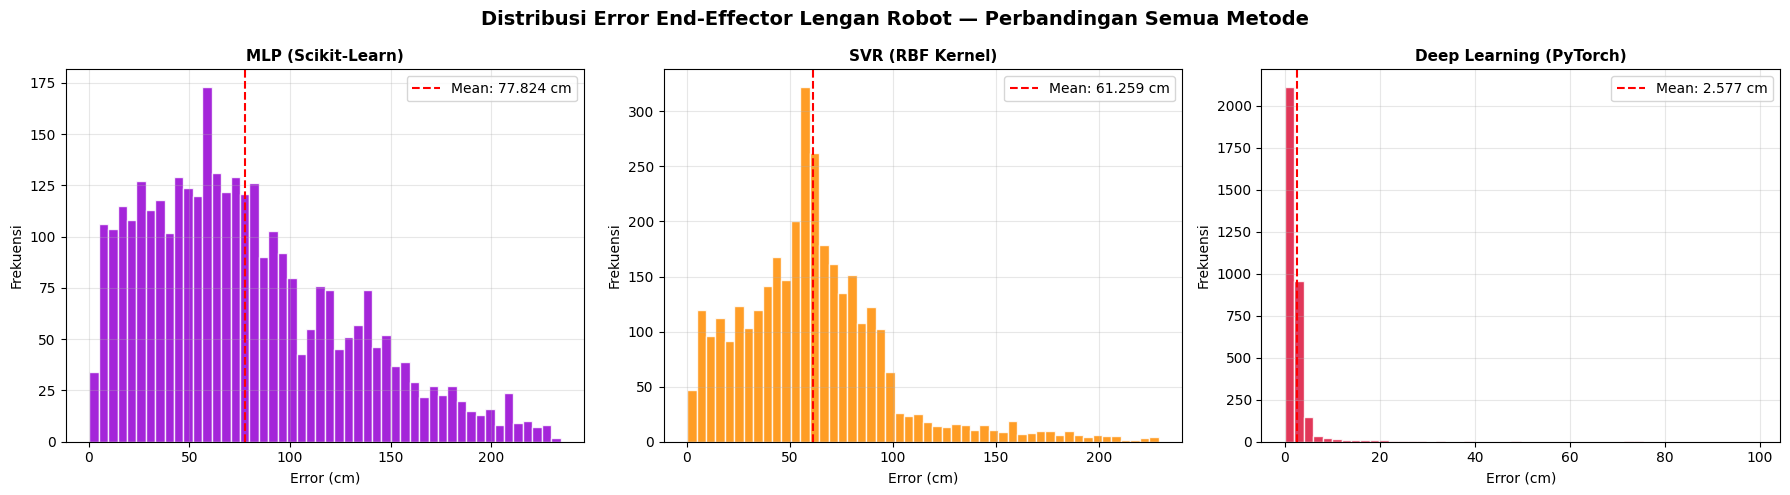

In [34]:
# ─── Distribusi Error Semua Metode ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

all_errs = [
    ('MLP (Scikit-Learn)', ml_results['MLP']['ee_err']*100, 'darkviolet'),
    ('SVR (RBF Kernel)', ml_results['SVR']['ee_err']*100, 'darkorange'),
    ('Deep Learning (PyTorch)', dl_err*100, 'crimson') # <--- Menambahkan data Deep Learning di sini
]

for ax, (name, errs, c) in zip(axes, all_errs):
    ax.hist(errs, bins=50, color=c, edgecolor='white', alpha=0.85)
    ax.axvline(errs.mean(), color='red', linestyle='--',
               label=f"Mean: {errs.mean():.3f} cm")
    ax.set_title(f"{name}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Error (cm)")
    ax.set_ylabel("Frekuensi")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Distribusi Error End-Effector Lengan Robot — Perbandingan Semua Metode",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📝 Kesimpulan & Diskusi


| Kondisi | Rekomendasi |
|---------|-------------|
| Butuh proses training yang cepat dan konsisten | **SVR (Support Vector Regression)** |
| Butuh akurasi fisis tertinggi dalam centimeter (cm) | **Deep Learning (IKNet PyTorch)** |
| Menangani lekukan workspace non-linear yang kompleks | **MLP Regressor (Scikit-Learn)** |
| Kontrol real-time di hardware berspesifikasi rendah | **SVR (RBF Kernel)** |
| Aproksimasi pemetaan sudut yang mulus dan kontinu | **MLP (Scikit-Learn / PyTorch)** |

---
*Selamat belajar! 🦾🤖*
